In [2]:
import os
import geopandas as gpd
print(os.getcwd())
os.chdir(r'C:\Users\solan\OneDrive\Desktop\IntrotoPython\FinalProj\cropfield-polygonization') # Change path to personal path to project

# Read File
zambia_shp = gpd.read_parquet(r'data\zambia_2023_attributed.parquet')

c:\Users\solan\OneDrive\Desktop\IntrotoPython\FinalProj\cropfield-polygonization\func


In [3]:
#Thinneckssss tester

import sys

# Adding path for importing polysplitter function
sys.path.insert(0, r'C:\Users\solan\OneDrive\Desktop\IntrotoPython\FinalProj\cropfield-polygonization\func')

from shapely.ops import split
from shapely.geometry import Point
from shapely.ops import nearest_points
from shapely import LineString
import pandas as pd

import importlib
import poly
import poly_recursive 
importlib.reload(poly)
importlib.reload(poly_recursive)
from poly import poly_splitter  
from poly_recursive import poly_splitter_recursive
from tile import tile_sampler

This file demonstrates and tests the `poly_recursive.py` `polysplitter_recursive` function and shows the development of this function. Examples are shown from the same `test_tile` used in `thinneck.ipynb`. 

In [4]:
# test_poly = tile_sampler(zambia_shp, 'tile_id', 'area_m2', 1000, None)
test_tile = zambia_shp[zambia_shp['tile_id'] == 883180]

# Look at the bottom 25% compactness, top 25% shape index, top 25% interior edge, top 25% fractal dim
test_tile_filt = test_tile[(test_tile["compactness"] <= test_tile["compactness"].quantile(0.25)) & (test_tile["shape_index"] >= test_tile["shape_index"].quantile(0.75)) & (test_tile["interior_edge"] >= test_tile["interior_edge"].quantile(0.75)) & (test_tile["fractal_dim"] >= test_tile["fractal_dim"].quantile(0.75))]

test_tile_filt = test_tile_filt.to_crs(32735)
test_tile = test_tile.to_crs(32735)

# test = poly_splitter(test_tile_filt, 'perimeter_m', 'geometry', delta=0.1)

The recursive function (shown in full below) repeats poly splitter function iteratively to see if additional splits need to be made for polygons for multiple thin necks. It does this by noting the row indices of all split rows, creating a new index for `cut_geom1` and `cut_geom2` values, removing split row indices from the original gdf indices, and then adding the new index lists for cut polygons. This allows us to plot both cut geometries from the same geometry column. 

In [ ]:

from poly import poly_splitter 
import pandas as pd 
import geopandas as gpd

#trying another version
def poly_splitter_recursive(gdf, perimeter_column, geometry_column, delta, max_iter, iter):
    if iter >= max_iter:
        print(f"Max no. of iterations ({max_iter}) reached")
        return gdf

    gdf = gdf.reset_index(drop=True)

    res = poly_splitter(gdf, perimeter_column, geometry_column, delta)
    if res['cut_geom1'].isna().all():
        print(f"No more splits")
        return gdf

    final_split_geom = []
    split_index = []
    new_idx = len(gdf)  # start after existing rows

    for idx, row in res.iterrows():
        if pd.isna(res.at[idx, 'cut_geom1']):
            continue

        split_index.append(idx)  

        row1 = row.copy()
        row1.name = new_idx
        row1[geometry_column] = res.at[idx, 'cut_geom1']
        row1[perimeter_column] = res.at[idx, 'cut_geom1'].length
        print(f"  storing row1: area={row1[geometry_column].area:.1f}, type={row1[geometry_column].geom_type}")
        new_idx += 1

        row2 = row.copy()
        row2.name = new_idx
        row2[geometry_column] = res.at[idx, 'cut_geom2']
        row2[perimeter_column] = res.at[idx, 'cut_geom2'].length
        print(f"  storing row2: area={row2[geometry_column].area:.1f}, type={row2[geometry_column].geom_type}")
        new_idx += 1

        final_split_geom.extend([row1, row2])

    gdf_unsplit = gdf.drop(index=split_index)
    final_geom_gdf = gpd.GeoDataFrame(final_split_geom, geometry=geometry_column, crs=gdf.crs)
    final_combined_gdf = pd.concat([gdf_unsplit, final_geom_gdf])  # no ignore_index

    return poly_splitter_recursive(final_combined_gdf, perimeter_column, geometry_column, delta, max_iter, iter + 1)

Here is are additional examples using sample polygons from `test_tile`. The first image in each chunk is the original polygon; the second image is the split polygon

,area_m2,area_ha,perimeter_m,compactness,shape_index,interior_edge,fractal_dim,tile_id,polygon_index,polygon_id,geometry
8104661,1949.296647,0.19493,206.383585,0.575092,1.318655,0.105876,1.40715,883180.0,274.0,8.831800e+11,"POLYGON ((219821.993 8519634.298, 219813.803 8519639.751, 219816.311 8519659.16, 219802.844 8519650.712, 219786.522 8519656.079, 219775.476 8519675.347, 219797.075 8519683.879, 219816.05 8519684.078, 219824.298 8519673.088, 219837.881 8519670.461, 219848.839 8519659.5, 219846.215 8519651.165, 219821.993 8519634.298))"


Split at row 0, buffer distance 8.100
  storing row1: area=1095.9, type=Polygon
  storing row2: area=855.7, type=Polygon
No split for row 0 within max_len=127.28364327503019
No split for row 1 within max_len=113.0535347330024
No more splits


<Axes: >

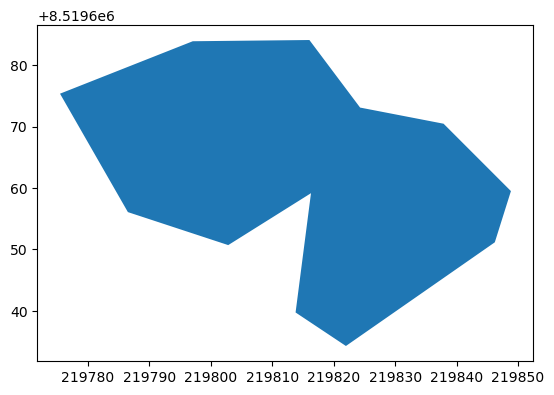

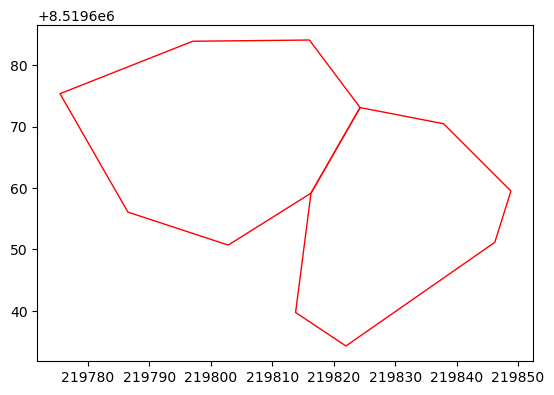

In [7]:
#test poly at row 1294
test_poly4 = test_tile.iloc[[274]]
pd.set_option('display.max_colwidth', None)
display(test_poly4)
test_poly4.plot()
test_poly4_res = poly_splitter_recursive(test_poly4, 'perimeter_m', 'geometry', delta = 0.1, max_iter = 5, iter = 0)
test_poly4_res.plot(facecolor = 'none', edgecolor = 'red')

Split at row 0, buffer distance 7.500
  storing row1: area=5291.9, type=Polygon
  storing row2: area=1996.7, type=Polygon
Split at row 0, buffer distance 14.200
Split at row 1, buffer distance 10.700
  storing row1: area=3689.2, type=Polygon
  storing row2: area=1602.7, type=Polygon
  storing row1: area=1287.3, type=Polygon
  storing row2: area=709.3, type=Polygon
Split at row 0, buffer distance 16.500
No split for row 1 within max_len=167.82465825914076
No split for row 2 within max_len=144.17135481009075
No split for row 3 within max_len=106.6122117275964
  storing row1: area=1941.4, type=Polygon
  storing row2: area=1747.8, type=Polygon
No split for row 0 within max_len=167.82465825914076
No split for row 1 within max_len=144.17135481009075
No split for row 2 within max_len=106.6122117275964
No split for row 3 within max_len=171.9660753616713
No split for row 4 within max_len=163.11461409606844
No more splits


<Axes: >

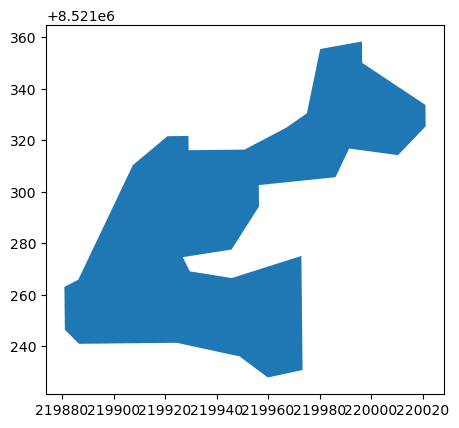

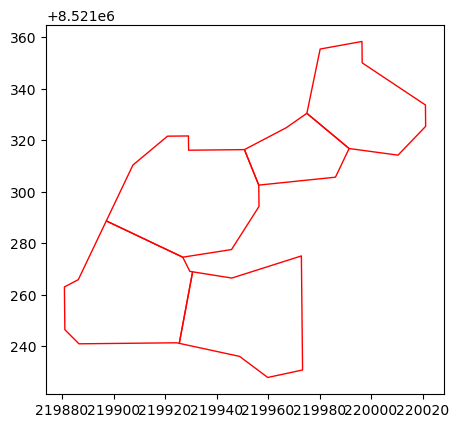

In [432]:
#test poly at row 468
test_poly5 = test_tile.iloc[[468]]
test_poly5.plot()
test_poly5_res = poly_splitter_recursive(test_poly5, 'perimeter_m', 'geometry', delta = 0.1, max_iter = 5, iter = 0)
test_poly5_res.plot(facecolor = 'none', edgecolor = 'red')

Split at row 0, buffer distance 1.400
  storing row1: area=6454.5, type=Polygon
  storing row2: area=6056.7, type=Polygon
Split at row 0, buffer distance 11.100
Split at row 1, buffer distance 35.800
  storing row1: area=5591.1, type=Polygon
  storing row2: area=863.4, type=Polygon
Split at row 0, buffer distance 35.800
No split for row 1 within max_len=329.46051793172876
No split for row 2 within max_len=116.38700569729855
No more splits


<Axes: >

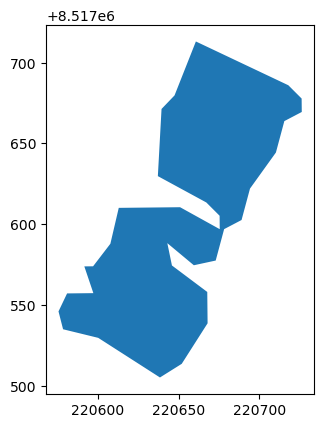

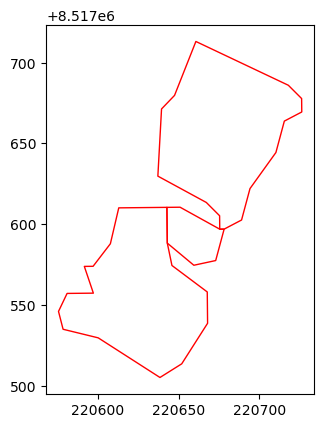

In [433]:
#test poly at row 541
test_poly6 = test_tile.iloc[[684]]
test_poly6.plot()
test_poly6_res = poly_splitter_recursive(test_poly6, 'perimeter_m', 'geometry', delta = 0.1, max_iter = 5, iter = 0)
test_poly6_res.plot(facecolor = 'none', edgecolor = 'red')

Split at row 0, buffer distance 4.200
  storing row1: area=5842.6, type=Polygon
  storing row2: area=4341.6, type=Polygon
No split for row 0 within max_len=313.4831385582497
Split at row 1, buffer distance 15.000
  storing row1: area=2769.3, type=Polygon
  storing row2: area=1572.3, type=Polygon
No split for row 0 within max_len=313.4831385582497
No split for row 1 within max_len=210.18200883660245
No split for row 2 within max_len=188.52037847956126
No more splits


<Axes: >

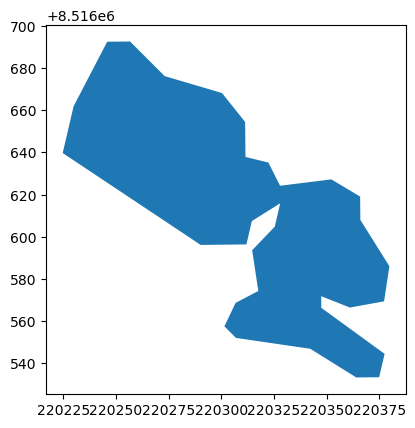

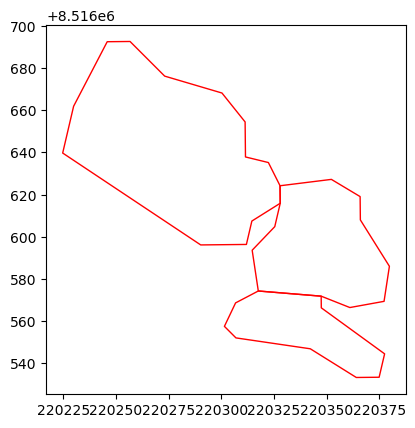

In [434]:
#test poly at row 489
test_poly3 = test_tile.iloc[[489]]
test_poly3.plot()
test_poly3_res = poly_splitter_recursive(test_poly3, 'perimeter_m', 'geometry', delta = 0.1, max_iter = 5, iter = 0)
test_poly3_res.plot(facecolor = 'none', edgecolor = 'red')

The example below shows how the number of iterations through the recursion function determines how split up a polygon will be. This value will likely need to be fine tuned.

Split at row 0, buffer distance 3.900
  storing row1: area=13123.1, type=Polygon
  storing row2: area=9497.9, type=Polygon
Split at row 0, buffer distance 4.300
Split at row 1, buffer distance 5.900
  storing row1: area=11209.2, type=Polygon
  storing row2: area=1913.9, type=Polygon
  storing row1: area=6531.4, type=Polygon
  storing row2: area=2966.5, type=Polygon
Max no. of iterations (2) reached
Split at row 0, buffer distance 3.900
  storing row1: area=13123.1, type=Polygon
  storing row2: area=9497.9, type=Polygon
Split at row 0, buffer distance 4.300
Split at row 1, buffer distance 5.900
  storing row1: area=11209.2, type=Polygon
  storing row2: area=1913.9, type=Polygon
  storing row1: area=6531.4, type=Polygon
  storing row2: area=2966.5, type=Polygon
Split at row 0, buffer distance 14.500
Split at row 1, buffer distance 8.800
No split for row 2 within max_len=349.78150908413966
No split for row 3 within max_len=228.47300858292922
  storing row1: area=10470.5, type=Polygon
  st

<Axes: >

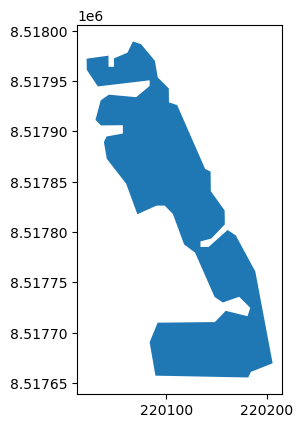

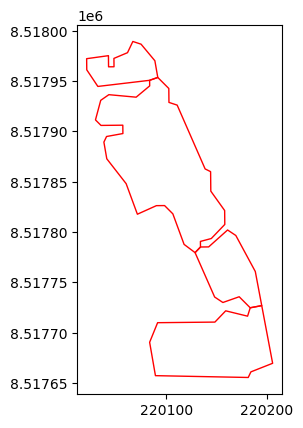

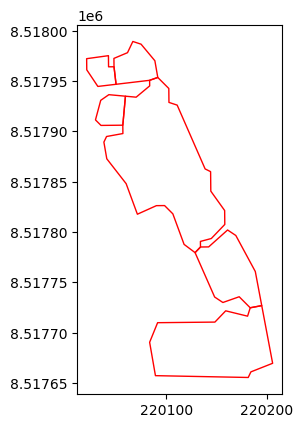

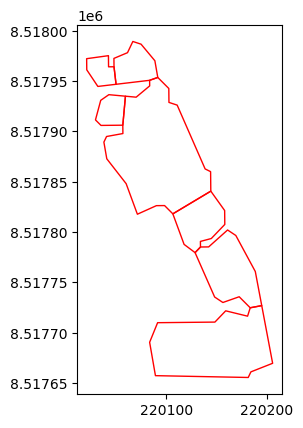

In [448]:
# Try test polygon at 24.426981 E 13.3715309 S  

test_poly1 = test_tile.loc[[8104758]]
test_poly1.plot()
test_poly1_res1 = poly_splitter_recursive(test_poly1, 'perimeter_m', 'geometry', 0.1, 2, 0)
test_poly1_res1.plot(facecolor='none', edgecolor='red', linewidth=1)
test_poly1_res2 = poly_splitter_recursive(test_poly1, 'perimeter_m', 'geometry', 0.1, 3, 0)
test_poly1_res2.plot(facecolor='none', edgecolor='red', linewidth=1)
test_poly1_res3 = poly_splitter_recursive(test_poly1, 'perimeter_m', 'geometry', 0.1, 4, 0)
test_poly1_res3.plot(facecolor='none', edgecolor='red', linewidth=1)

This code does fail in particular for cases when there are holes in the polygons - it would be beneficial to run the polygon cut out function to fix false cut outs before running this polygon splitter function. 

Split at row 0, buffer distance 6.800
No more splits


<Axes: >

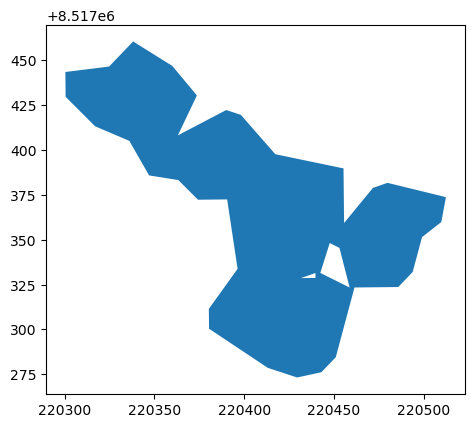

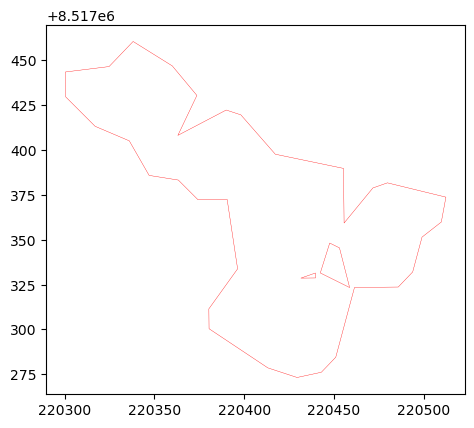

In [450]:
test_poly2 = test_tile.loc[[8104902]]
test_poly2.plot()
test_poly2_res = poly_splitter_recursive(test_poly2, 'perimeter_m', 'geometry', delta=0.1, max_iter=5, iter=0)
test_poly2_res.plot(facecolor = 'none', edgecolor = 'red', linewidth = 0.25)

Now let's try running this on the entirety of the `test_tile` and examining the results in ArcGISPro:

In [ ]:
test_tile_res = poly_splitter_recursive(test_tile, 'perimeter_m', 'geometry', 0.1, 5, 0)

In [ ]:
test_tile_res.to_file(r"C:\Users\solan\OneDrive\Desktop\IntrotoPython\FinalProj\cropfield-polygonization\data\cropfieldtest.gpkg", layer="cropfieldtest", driver="GPKG")

print("GeoPackage file created successfully.")